In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
print(sys.executable)

d:\miniconda\envs\shumo\python.exe


这是一个markdown单元格，按shift+enter运行

# 2.Python基础语法

In [3]:
city = "成都"
gdp = 23500
population = 2140

per_capita_gdp = gdp / population  #除法/

print(city)
print("人均GDP:",per_capita_gdp,"亿元/万人")
print(f"人均GDP:{per_capita_gdp:.2f}亿元/万人")

成都
人均GDP: 10.981308411214954 亿元/万人
人均GDP:10.98亿元/万人


In [4]:
a = 10
b = 3.13
c = "数学建模"
d = True

print(type(a),type(b),type(c),type(d))

<class 'int'> <class 'float'> <class 'str'> <class 'bool'>


## 列表与字典
列表适合保存一组有顺序的数据，字典适合保存"名称-数值"这样的对应关系

In [5]:
cities = ["成都","绵阳","德阳","宜宾"]
scores = [88.5,81.2,76.9,79.4]

score_dict = {
    "成都":88.5,
    "绵阳":81.2,
    "德阳":76.9,
    "宜宾":79.4
}
print(cities)
print(cities[0])
print(cities[1:3])
print(score_dict["成都"])


['成都', '绵阳', '德阳', '宜宾']
成都
['绵阳', '德阳']
88.5


# 条件判断

In [6]:
score = 83

if score >= 85:
    level = "优秀"
elif score >=75:
    level = "良好"
elif score >= 60:
    level = "合格"
else:
    level = "待提升"

print("等级：",level)

等级： 良好


## 循环

In [7]:
for city,score in score_dict.items():
    print(city,"综合得分：",score)

sum = 0
for i in range(1,101):
    sum += i
print(sum)

成都 综合得分： 88.5
绵阳 综合得分： 81.2
德阳 综合得分： 76.9
宜宾 综合得分： 79.4
5050


## 函数
这个公式会把一组数据转化到0到1之间

In [8]:
def min_max_normalize(x):
    x = np.array(x,dtype=float)
    return (x-x.min()) / (x.max()-x.min())

values = [80,95,70,88]
normalized_values = min_max_normalize(values)
print(normalized_values)

[0.4  1.   0.   0.72]


# 3.numpy:数值计算基础
numpy适合处理数组、矩阵和批量数值运算。数学建模中很多模型最终都会转化成数组或矩阵计算

In [9]:
x = np.array([80,90,75,88,92]) #列表里的元素必须是数值型的

print("原始数组：",x )
print("平均值：",x.mean())
print(f"平均值：{np.mean(x)}")
print("标准差：",x.std())


原始数组： [80 90 75 88 92]
平均值： 85.0
平均值：85.0
标准差： 6.44980619863884


In [10]:
#手动计算均值，与numpy效果对比
manual_mean = np.sum(x) / len(x)
print("手动计算均值:",manual_mean)
print("numpy计算均值:",np.mean(x))

手动计算均值: 85.0
numpy计算均值: 85.0


## 4.pandas:表格数据处理
pandas是数学建模中最常用的数据处理库。可以把DataFrame理解成Python中的Excel表格

In [11]:
data = {
    "城市":["成都","绵阳","德阳","宜宾"],
    "GDP_亿元":[23500,4038,3020,3807],
    "人口_万人":[2140,490,345,458],
    "绿化率_%":[42.8,41.2,39.5,43.6]
}

df_demo = pd.DataFrame(data)
df_demo

,城市,GDP_亿元,人口_万人,绿化率_%
0,成都,23500,2140,42.8
1,绵阳,4038,490,41.2
2,德阳,3020,345,39.5
3,宜宾,3807,458,43.6


### 4.1查看数据
建模开始时，通常先查看数据结构，前几行、字段名称和描述性统计

In [12]:
print("数据形状：",df_demo.shape)
print("字段名称:",list(df_demo.columns))

df_demo.head(2) #这个数字表示查前几行数据，不填默认是前5行

数据形状： (4, 4)
字段名称: ['城市', 'GDP_亿元', '人口_万人', '绿化率_%']


,城市,GDP_亿元,人口_万人,绿化率_%
0,成都,23500,2140,42.8
1,绵阳,4038,490,41.2


In [13]:
df_demo.describe()

,GDP_亿元,人口_万人,绿化率_%
count,4.000000,4.000000,4.000000
mean,8591.250000,858.250000,41.775000
std,9948.714938,856.760711,1.815443
min,3020.000000,345.000000,39.500000
25%,3610.250000,429.750000,40.775000
50%,3922.500000,474.000000,42.000000
75%,8903.500000,902.500000,43.000000
max,23500.000000,2140.000000,43.600000


### 4.2新增计算列


In [14]:
df_demo["人均GDP_万元每人"] = df_demo["GDP_亿元"]/df_demo["人口_万人"]
df_demo

,城市,GDP_亿元,人口_万人,绿化率_%,人均GDP_万元每人
0,成都,23500,2140,42.8,10.981308
1,绵阳,4038,490,41.2,8.240816
2,德阳,3020,345,39.5,8.753623
3,宜宾,3807,458,43.6,8.312227


## 5.matplotlib:基础可视化
图表可以帮助发现数据差异，也能作为论文中的结果展示。绘图时需要注意标题、坐标轴、单位和图例

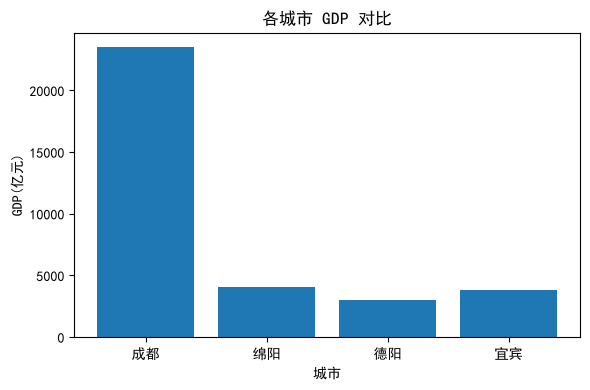

In [15]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(6,4))  #分辨率，数值越大图越清晰
plt.bar(df_demo["城市"],df_demo["GDP_亿元"]) #条形图代码 横轴纵轴
plt.title("各城市 GDP 对比")
plt.xlabel("城市")
plt.ylabel("GDP(亿元)")
plt.tight_layout() #让图更紧凑
plt.show()

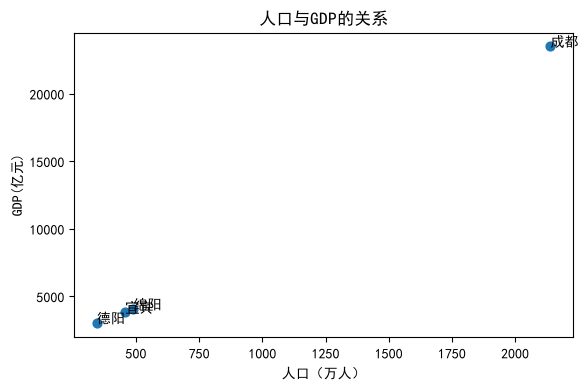

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df_demo["人口_万人"],df_demo["GDP_亿元"],s=40)  #散点图 横轴纵轴 s表示散点大小
for _,row in df_demo.iterrows():
    plt.text(row["人口_万人"],row["GDP_亿元"],row["城市"],fontsize=10)
plt.title("人口与GDP的关系")
plt.xlabel("人口（万人）")
plt.ylabel("GDP(亿元)")
plt.tight_layout()
plt.show()

In [19]:
# 构造示例数据，并保存为 CSV 和 Excel
city_data = pd.DataFrame({
    "城市": ["成都", "绵阳", "德阳", "宜宾", "泸州", "南充", "乐山", "眉山", "自贡", "达州"],
    "GDP_亿元": [23500, 4038, 3020, 3807, 2726, 2685, 2448, 1730, 1750, 2502],
    "人口_万人": [2140, 490, 345, 458, 426, 555, 315, 295, 245, 535],
    "绿化率_%": [42.8, 41.2, 39.5, 43.6, 38.4, 40.1, 45.2, 44.0, 37.5, 39.0],
    "平均通勤时间_分钟": [38, 29, 31, 33, 34, 32, 28, 30, 36, 35],
    "普通高校数": [65, 14, 7, 8, 6, 7, 5, 4, 4, 5]
})

csv_path = "第二讲示例数据.csv"
xlsx_path = "第二讲示例数据.xlsx"
city_data.to_csv(csv_path, index=False, encoding="utf-8-sig")
city_data.to_excel(xlsx_path, index=False)
print("Saved files:", csv_path, xlsx_path)
city_data.head()


Saved files: 第二讲示例数据.csv 第二讲示例数据.xlsx


,城市,GDP_亿元,人口_万人,绿化率_%,平均通勤时间_分钟,普通高校数
0,成都,23500,2140,42.8,38,65
1,绵阳,4038,490,41.2,29,14
2,德阳,3020,345,39.5,31,7
3,宜宾,3807,458,43.6,33,8
4,泸州,2726,426,38.4,34,6


In [25]:
#读取刚才保存的数据
file_path = "第二讲示例数据.csv"
city_df = pd.read_csv(file_path)
city_df


,城市,GDP_亿元,人口_万人,绿化率_%,平均通勤时间_分钟,普通高校数
0,成都,23500,2140,42.8,38,65
1,绵阳,4038,490,41.2,29,14
2,德阳,3020,345,39.5,31,7
3,宜宾,3807,458,43.6,33,8
4,泸州,2726,426,38.4,34,6
5,南充,2685,555,40.1,32,7
6,乐山,2448,315,45.2,28,5
7,眉山,1730,295,44.0,30,4
8,自贡,1750,245,37.5,36,4
9,达州,2502,535,39.0,35,5


### 7.1数据基本查看
info()用于查看字段类型和缺失情况，describe()用于查看数值字段的描述性统计。

In [26]:
city_df.info()
city_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   城市         10 non-null     str    
 1   GDP_亿元     10 non-null     int64  
 2   人口_万人      10 non-null     int64  
 3   绿化率_%      10 non-null     float64
 4   平均通勤时间_分钟  10 non-null     int64  
 5   普通高校数      10 non-null     int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 612.0 bytes


(10, 6)

In [22]:
city_df.describe()

,GDP_亿元,人口_万人,绿化率_%,平均通勤时间_分钟,普通高校数
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,4820.600000,580.400000,41.130000,32.600000,12.500000
std,6605.853115,557.957426,2.636938,3.204164,18.674106
min,1730.000000,245.000000,37.500000,28.000000,4.000000
25%,2461.500000,322.500000,39.125000,30.250000,5.000000
50%,2705.500000,442.000000,40.650000,32.500000,6.500000
75%,3610.250000,523.750000,43.400000,34.750000,7.750000
max,23500.000000,2140.000000,45.200000,38.000000,65.000000
